# nanochat: A Minimal Language Model in Pure JAX
## Yoav Ram

This notebook implements the [NanoChat GPT](https://github.com/karpathy/nanochat) architecture from scratch in pure JAX.

### Architecture
- Rotary Position Embeddings (RoPE)
- QK Normalisation 
- ReLU² MLP
- Pre-norm with RMSNorm
- Untied token embedding and LM head

### Key JAX concepts illustrated
- Parameters as explicit **pytree dicts** (not bound to an object)
- Pure **functional** forward pass — no mutable state
- **`jax.value_and_grad`** for loss and gradients in one call
- **`jax.jit`** compilation of the training step
- Explicit **PRNG key splitting** for reproducible randomness
- **`jax.vmap`** for batched operations

## Language Model

As in RNN, we use the autoregressive factorisation for predicting the next token:

$$p(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, \ldots, x_{t-1})$$

As in other classifiers, we use cross entropy loss:

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log P(x_t \mid x_{<t})$$

Minimising $\mathcal{L}$ is equivalent to maximising the joint log-likelihood.

Other metrics of interest:
- Perplexity: $\text{ppl} = \exp(\mathcal{L})$
- Bits-per-token: $\text{bpt} = \mathcal{L} / \log 2$

With BPE tokenisation the loss measures bits per token.
To convert to the standard bits-per-byte (bpb) metric used to compare across tokenisers, multiply by the compression ratio $r$ (tokens / characters):

$$\text{bpb} = \text{bpt} \times r$$

For English text with a 50k BPE vocabulary $r \approx 0.25$ and a well-trained model achieves bpb ≈ 1.0–1.5.
With our small 512-token vocabulary $r$ is larger (~0.3–0.4), so bpt and bpb are closer together.

In [1]:
import os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import math
import pickle
import optax
from functools import partial

key = jax.random.key(2287)

In [2]:
def cross_entropy_loss(logits, targets):
    """
    logits : (B*T, V) float32
    targets: (B*T,)  int32
    Returns scalar mean cross-entropy.
    """
    log_probs = jax.nn.log_softmax(logits, axis=-1) # (B*T, V)
    # Gather log-prob of the correct token at each position
    correct = log_probs[jnp.arange(targets.shape[0]), targets] # (B*T,)
    return -jnp.mean(correct)

def bits_per_byte(loss):
    return loss / jnp.log(2)

# Sanity check
B, T, V = 2, 3, 10
key, sub = jax.random.split(key)
logits  = jax.random.normal(sub, (B * T, V))
targets = jax.random.randint(key, (B * T,), 0, V)
loss = cross_entropy_loss(logits, targets)
print(f"Cross-entropy loss: {loss:.4f}")
print(f"Bits per byte:      {bits_per_byte(loss):.4f}")

Cross-entropy loss: 2.5872
Bits per byte:      3.7325


## Tokenisation

We previously built character-level models (RNN, GRU, Transformer on Shakespeare dataset).
They work, but share a key limitation: **long sequences**.
The word "evolution" takes 9 steps; "natural selection" takes 17.
Transformer attention costs O(T²) in sequence length, so shorter sequences matter a lot.

Modern LLMs use **sub-word tokenisation**: split text into frequently occurring substrings
so that common words become single tokens, rare words split into meaningful pieces,
and the vocabulary stays compact.

| Method | Vocab size | Avg chars/token | Used by |
|--------|-----------|-----------------|---------|
| Character | ~100 | 1.0 | Previous course (RNN/GRU/Transformer) |
| **BPE** | **512** | **~3–4** | **GPT-2/3/4, LLaMA** |
| WordPiece | 30k | ~4–5 | BERT |
| Unigram LM | 8k–32k | ~4–6 | SentencePiece, T5 |

We will use BPE tokenization, implemented in [bpe_tokenizer.ipynb](bpe_tokenizer.ipynb).

In [3]:
from bpe import bpe_encode, bpe_decode, bpe_load

# Quick demo
vocab_demo, merges_demo = bpe_load('bpe_tokenizer.pkl')
sample = "Once upon a time there was"
ids = bpe_encode(sample, vocab_demo, merges_demo)
print(f"vocab_size: {len(vocab_demo)}")
print(f"'{sample}'")
print(f"  → {[vocab_demo[i] for i in ids]}")

vocab_size: 512
'Once upon a time there was'
  → ['On', 'ce upon a tim', 'e ', 'there ', 'was']


## Transformer Architecture

In pure JAX, the model has no classes that hold parameters.
Instead:

- `init_params(key, config)` — returns a **plain Python dict** (a JAX pytree)
- `forward(params, x, cos, sin, mask)` — a **pure function**; same inputs always give same outputs

This functional style makes `jax.jit`, `jax.vmap`, and `jax.grad` trivial to apply.

### RMSNorm

Pre-norm (applied *before* each sub-layer) stabilises training.
NanoChat uses **RMSNorm** (no bias, no mean subtraction):

$$\text{RMSNorm}(\mathbf{x}) = g \cdot \frac{\mathbf{x}}{\sqrt{\frac{1}{d}\sum_i x_i^2 + \epsilon}}$$

where $g \in \mathbb{R}^d$ is a learned gain initialised to 1.


In [4]:
def rms_norm(g, x, eps=1e-6):
    """
    g : (d,)         learned gain
    x : (..., d)     input tensor
    """
    rms = jnp.sqrt(jnp.mean(x**2, axis=-1, keepdims=True) + eps)
    return g * (x / rms)

# Test: norm is ~1 after normalisation
key, sub = jax.random.split(key)
x = jax.random.normal(sub, (4, 16, 64))
g = jnp.ones(64)
y = rms_norm(g, x)
print(f"Input  RMS: {jnp.sqrt(jnp.mean(x**2, axis=-1)).mean():.3f}")
print(f"Output RMS: {jnp.sqrt(jnp.mean(y**2, axis=-1)).mean():.3f}  (≈1.0)")

Input  RMS: 0.993
Output RMS: 1.000  (≈1.0)


### Rotary Position Embeddings (RoPE)

RoPE ([Su et al. 2021](https://arxiv.org/abs/2104.09864)) encodes position $m$ by rotating each 2D subspace of the query/key vector:

$$\mathbf{v}'_{2i}, \mathbf{v}'_{2i+1} =
\mathbf{v}_{2i} \cos(m\theta_i) - \mathbf{v}_{2i+1} \sin(m\theta_i),\;
\mathbf{v}_{2i} \sin(m\theta_i) + \mathbf{v}_{2i+1} \cos(m\theta_i)$$

where $\theta_i = 10000^{-2i/d}$.

Because the rotation preserves norms, the inner product
$\langle \mathbf{q}_m, \mathbf{k}_n \rangle$ 
depends only on the **relative position** $m - n$, giving a natural inductive bias for sequence order.

We precompute the cosine/sine tables once; they are passed as constants into every forward call (no stateful buffer).

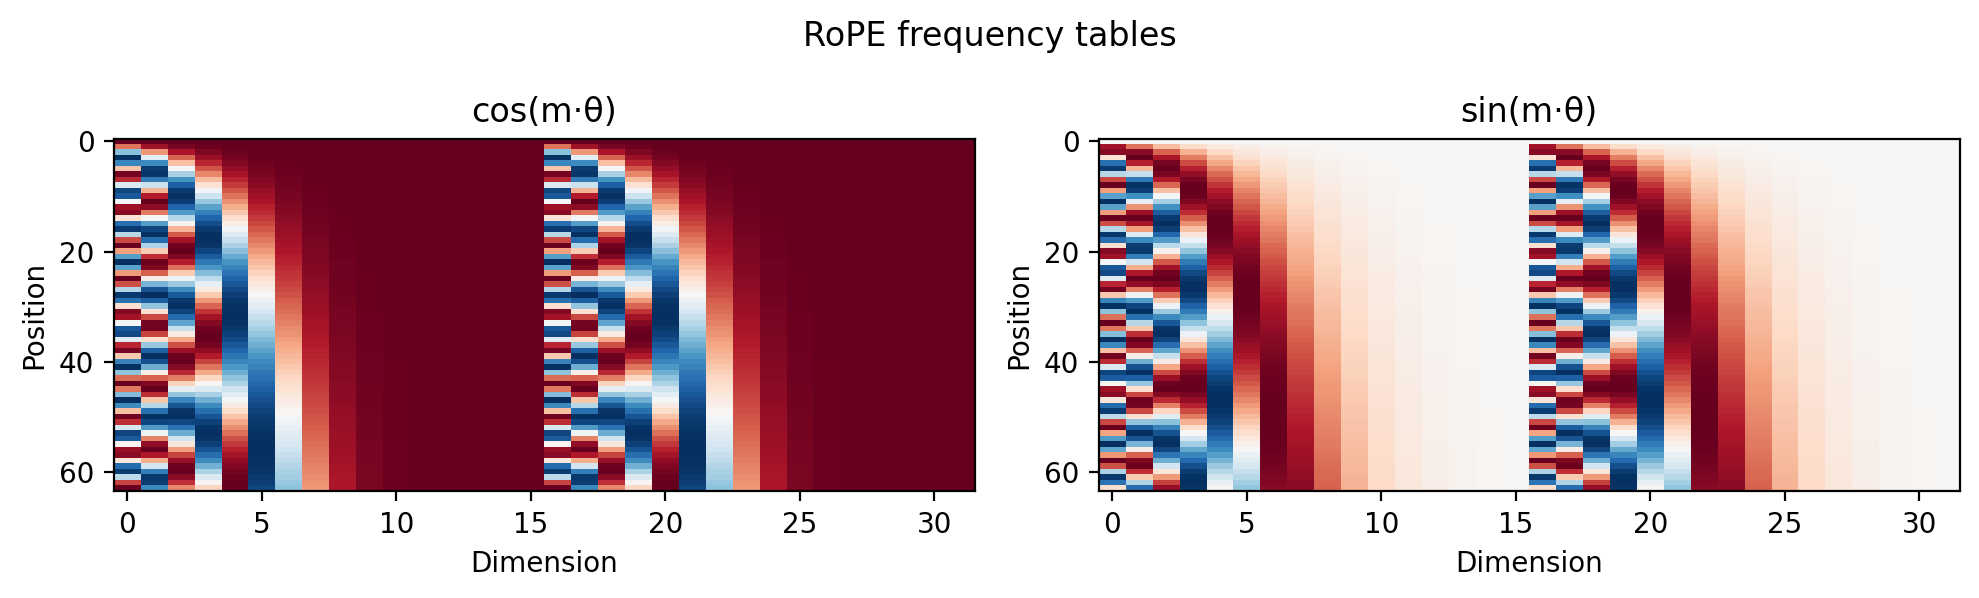

Norm preserved: True


In [5]:
def precompute_rope(seq_len: int, head_dim: int, base: float = 10000.0):
    """
    Returns cos, sin arrays of shape (seq_len, head_dim).
    Precomputed once; passed as constants to forward().
    """
    i      = jnp.arange(0, head_dim, 2)          # (head_dim//2,)
    theta  = 1.0 / (base ** (i / head_dim))       # frequencies
    pos    = jnp.arange(seq_len)                  # (seq_len,)
    angles = jnp.outer(pos, theta)                # (seq_len, head_dim//2)
    angles = jnp.concatenate([angles, angles], axis=-1)  # (seq_len, head_dim)
    return jnp.cos(angles), jnp.sin(angles)       # both (seq_len, head_dim)

def rotate_half(x):
    """Rotate the last dimension in pairs: [x1, x2] -> [-x2, x1]."""
    d = x.shape[-1] // 2
    return jnp.concatenate([-x[..., d:], x[..., :d]], axis=-1)

def apply_rope(x, cos, sin):
    """
    x   : (..., T, head_dim)
    cos : (T, head_dim) or broadcastable
    sin : (T, head_dim) or broadcastable
    """
    return x * cos + rotate_half(x) * sin

# Visualise RoPE frequency table
seq_len, head_dim = 64, 32
cos_table, sin_table = precompute_rope(seq_len, head_dim)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].imshow(cos_table, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set(title='cos(m·θ)', xlabel='Dimension', ylabel='Position')
axes[1].imshow(sin_table, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set(title='sin(m·θ)', xlabel='Dimension', ylabel='Position')
plt.suptitle('RoPE frequency tables', fontsize=12)
plt.tight_layout()
plt.show()

# Verify norm is preserved after rotation
key, sub = jax.random.split(key)
x = jax.random.normal(sub, (2, seq_len, head_dim))
cos_, sin_ = precompute_rope(seq_len, head_dim)
x_rot = apply_rope(x, cos_, sin_)
print(f"Norm preserved: {jnp.allclose(jnp.linalg.norm(x, axis=-1), jnp.linalg.norm(x_rot, axis=-1), atol=1e-5)}")


### Causal Self-Attention with QK Normalisation

$$\text{Attention}(\mathbf{Q}', \mathbf{K}', \mathbf{V}) =
\text{softmax}\!\left(\frac{\mathbf{Q}'\mathbf{K}'^\top}{\sqrt{d_k}} + M\right) \mathbf{V}$$

where $\mathbf{Q}' = \mathbf{Q}/\|\mathbf{Q}\|_2$, $\mathbf{K}' = \mathbf{K}/\|\mathbf{K}\|_2$
are L2-normalised per-token (QK Norm), and $M$ is the causal mask
($M_{ij} = -\infty$ for $j > i$, else 0).

**QK Norm** prevents unbounded dot-product growth, improving gradient flow and
optimizer stability. It is equivalent to computing cosine similarities rather
than raw inner products.

In JAX the attention function is a pure function over arrays; no module, no buffer, no mutable state.


In [6]:
def attention_forward(params_attn, x, cos, sin, mask):
    """
    params_attn : dict with Wq, Wk, Wv, Wo each (d_model, d_model)
    x           : (B, T, d_model)
    cos, sin    : (T, head_dim)
    mask        : (T, T)
    Returns     : (B, T, d_model), attn_weights (B, n_heads, T, T)
    """
    B, T, d = x.shape
    head_dim = cos.shape[-1]   # concrete: inferred from RoPE table shape
    n_heads  = d // head_dim   # concrete: integer division of static dims

    Wq, Wk, Wv, Wo = (params_attn['Wq'], params_attn['Wk'],
                       params_attn['Wv'], params_attn['Wo'])

    # Linear projections
    Q = x @ Wq                    # (B, T, d)
    K = x @ Wk
    V = x @ Wv

    # Reshape to (B, T, n_heads, head_dim)
    def split_heads(t):
        return t.reshape(B, T, n_heads, head_dim).transpose(0, 2, 1, 3)  # (B, H, T, hd)

    Q, K, V = split_heads(Q), split_heads(K), split_heads(V)

    # Apply RoPE (broadcast over batch and head dims)
    cos_ = cos[None, None, :, :]   # (1, 1, T, head_dim)
    sin_ = sin[None, None, :, :]
    Q = apply_rope(Q, cos_, sin_)
    K = apply_rope(K, cos_, sin_)

    # QK Normalisation (L2 per token per head)
    Q = Q / (jnp.linalg.norm(Q, axis=-1, keepdims=True) + 1e-6)
    K = K / (jnp.linalg.norm(K, axis=-1, keepdims=True) + 1e-6)

    # Scaled dot-product attention
    scale  = math.sqrt(head_dim)
    scores = (Q @ K.transpose(0, 1, 3, 2)) / scale   # (B, H, T, T)
    scores = scores + mask[None, None, :, :]           # causal mask
    weights = jax.nn.softmax(scores, axis=-1)          # (B, H, T, T)

    # Weighted sum of values
    out = weights @ V                                  # (B, H, T, hd)
    out = out.transpose(0, 2, 1, 3).reshape(B, T, d)  # (B, T, d)
    out = out @ Wo                                     # (B, T, d)
    return out, weights

def causal_mask(seq_len: int):
    """Lower-triangular causal mask: 0 where allowed, -inf where masked."""
    mask = jnp.tril(jnp.ones((seq_len, seq_len)))
    return jnp.where(mask, 0.0, -jnp.inf)   # (T, T)

In [7]:
# Quick shape check
d_model, n_heads, T, B = 64, 4, 10, 2
head_dim = d_model // n_heads
key, *subs = jax.random.split(key, 6)
params_attn = {
    'Wq': jax.random.normal(subs[0], (d_model, d_model)) * 0.02,
    'Wk': jax.random.normal(subs[1], (d_model, d_model)) * 0.02,
    'Wv': jax.random.normal(subs[2], (d_model, d_model)) * 0.02,
    'Wo': jax.random.normal(subs[3], (d_model, d_model)) * 0.02,
}
mask_ = causal_mask(T)
cos_, sin_ = precompute_rope(T, head_dim)
x_  = jax.random.normal(subs[4], (B, T, d_model))
out, weights = attention_forward(params_attn, x_, cos_, sin_, mask_)
print(f"Attention output shape: {out.shape}")
print(f"Attention weights shape: {weights.shape}  (B, H, T, T)")
print(f"Causal mask respected: {jnp.all(weights[:, :, 0, 1:] == 0).item()}")

Attention output shape: (2, 10, 64)
Attention weights shape: (2, 4, 10, 10)  (B, H, T, T)
Causal mask respected: True


### MLP with ReLU²

$$\text{FFN}(\mathbf{x}) = \mathbf{W}_2\, \text{ReLU}^2(\mathbf{W}_1 \mathbf{x})$$

[ReLU²](https://arxiv.org/abs/2402.03804) is just the square of ReLU.
It encourages sparsity (inactive units remain exactly zero; active units grow
quadratically). Production models typically use GELU or SwiGLU for better scaling,
but ReLU² is used in the original nanochat.


In [8]:
def mlp_forward(params_mlp, x):
    """
    params_mlp: {'W1': (d, 4d), 'W2': (4d, d)}
    x         : (B, T, d)
    """
    h = x @ params_mlp['W1']              # (B, T, 4d)
    r = jax.nn.relu(h)                    # ReLU
    h = r * r                             # ReLU²
    return h @ params_mlp['W2']           # (B, T, d)

# Test
key, s1, s2 = jax.random.split(key, 3)
params_mlp = {
    'W1': jax.random.normal(s1, (64, 256)) * 0.02,
    'W2': jax.random.normal(s2, (256, 64)) * 0.02,
}
x_ = jax.random.normal(key, (2, 10, 64))
out = mlp_forward(params_mlp, x_)
print(f"MLP output shape: {out.shape}  (expected (2, 10, 64))")
print(f"Sparsity (fraction of zeros in hidden layer): "
      f"{jnp.mean(x_ @ params_mlp['W1'] <= 0):.2%}")


MLP output shape: (2, 10, 64)  (expected (2, 10, 64))
Sparsity (fraction of zeros in hidden layer): 48.71%


### nanochat

We assemble `init_params` and `forward` — no class, no state.

Parameter initialisation follows standard practice:
- Embedding weights: $\mathcal{N}(0, 0.02)$
- Linear weights: $\mathcal{N}(0, 0.02)$
- RMSNorm gains: $\mathbf{1}$
- LM head: separate weight matrix, untied from the token embedding (as in [karpathy/nanochat](https://github.com/karpathy/nanochat))

In [9]:
def init_params(key, vocab_size, d_model=128, n_heads=4, n_layers=4, d_ff=None):
    """
    Initialise all NanoChatGPT parameters as a plain nested dict (JAX pytree).

    Returns
    -------
    params : dict
        Nested dict — the sole source of model state.
    config : dict
        Hyperparameters needed by forward().
    """
    if d_ff is None:
        d_ff = 4 * d_model
    head_dim = d_model // n_heads

    def W(key, shape):
        return jax.random.normal(key, shape) * 0.02

    def new_key():
        nonlocal key
        key, sub = jax.random.split(key)
        return sub

    blocks = []
    for _ in range(n_layers):
        blocks.append({
            'norm1': {'g': jnp.ones(d_model)},
            'attn': {
                'Wq': W(new_key(), (d_model, d_model)),
                'Wk': W(new_key(), (d_model, d_model)),
                'Wv': W(new_key(), (d_model, d_model)),
                'Wo': W(new_key(), (d_model, d_model)),
            },
            'norm2': {'g': jnp.ones(d_model)},
            'mlp': {
                'W1': W(new_key(), (d_model, d_ff)),
                'W2': W(new_key(), (d_ff,  d_model)),
            },
        })

    params = {
        'tok_emb': {'W': W(new_key(), (vocab_size, d_model))},
        'blocks':  blocks,
        'norm_f':  {'g': jnp.ones(d_model)},
        'head':    {'W': W(new_key(), (vocab_size, d_model))},  # untied LM head
    }

    config = dict(vocab_size=vocab_size, d_model=d_model, n_heads=n_heads,
                  n_layers=n_layers, d_ff=d_ff, head_dim=head_dim)
    return params, config

V_test = 50
key_init = jax.random.key(993)
params, cfg = init_params(key_init, vocab_size=V_test, d_model=64, n_heads=4, n_layers=2)

In [10]:
def count_params(pytree):
    leaves = jax.tree_util.tree_leaves(pytree)
    return sum(x.size for x in leaves if hasattr(x, 'size'))

n_params = count_params(params)
print(f"Parameter count: {n_params:,}")

Parameter count: 105,024


In [11]:
def forward(params, token_ids, cos, sin, mask):
    """
    Pure-function forward pass — no side effects.

    Parameters
    ----------
    params    : pytree dict from init_params
    token_ids : (B, T) int array
    cos, sin  : (T, head_dim) RoPE tables
    mask      : (T, T) causal mask

    Returns
    -------
    logits : (B, T, vocab_size)
    """
    # Token embedding
    x = params['tok_emb']['W'][token_ids]   # (B, T, d_model)

    # Transformer blocks
    for blk in params['blocks']:
        # ── Self-attention with pre-norm ──────────────────────────────
        x_normed = rms_norm(blk['norm1']['g'], x)
        attn_out, _ = attention_forward(blk['attn'], x_normed, cos, sin, mask)
        x = x + attn_out

        # ── MLP with pre-norm ─────────────────────────────────────────
        x_normed = rms_norm(blk['norm2']['g'], x)
        x = x + mlp_forward(blk['mlp'], x_normed)

    # Final norm and LM head
    x = rms_norm(params['norm_f']['g'], x)        # (B, T, d_model)
    logits = x @ params['head']['W'].T            # (B, T, vocab_size)
    return logits

T_test = 16
cos_c, sin_c = precompute_rope(T_test, cfg['head_dim'])
mask_c = causal_mask(T_test)

ids = jax.random.randint(jax.random.key(1), (2, T_test), 0, V_test)
logits = forward(params, ids, cos_c, sin_c, mask_c)
print(f"Logits shape: {logits.shape}  (expected (2, {T_test}, {V_test}))")

Logits shape: (2, 16, 50)  (expected (2, 16, 50))


These functions are used to save and load _checkpoints_, which are states of the model and other variables like the vocabulary.

In [12]:
def save_checkpoint(params, cfg, vocab, merges, path='nanochat_checkpoint.pkl'):
    """Save params, config, and tokenizer vocab/merges to a pickle file."""
    with open(path, 'wb') as f:
        pickle.dump({'params': jax.tree_util.tree_map(np.array, params),
                     'cfg': cfg, 'vocab': vocab, 'merges': merges}, f)
    print(f'Checkpoint saved -> {path}')

def load_checkpoint(path='nanochat_checkpoint.pkl'):
    """Load params, config, vocab, and merges from a pickle file."""
    with open(path, 'rb') as f:
        s = pickle.load(f)
    vocab  = s['vocab']
    merges = [tuple(m) for m in s['merges']]
    return jax.tree_util.tree_map(jnp.array, s['params']), s['cfg'], vocab, merges

## Scaling Laws and Model Capacity

Language model performance follows predictable **power laws** in parameter count
$N$ and training tokens $D$ ([Kaplan et al. 2020](https://arxiv.org/abs/2001.08361)):

$$\mathcal{L}(N) \approx \left(\frac{N_0}{N}\right)^{\alpha_N}, \quad \alpha_N \approx 0.076$$

**Chinchilla optimality** ([Hoffmann et al. 2022](https://arxiv.org/abs/2203.15556)): for a fixed compute budget 
$C = 6ND$ FLOPs, the optimal allocation is $D \approx 20N$ tokens per parameter.


In [13]:
# Parameter count across model sizes — matches nanochat depth/aspect configs
configs = [
    ('tiny',    64,  4, 2),
    ('small',  128,  4, 4),
    ('medium', 256,  8, 6),
    ('large',  512,  8, 8),
]

print(f"{'Name':<10} {'d_model':>8} {'heads':>6} {'layers':>7} {'params':>12}")
print("-" * 50)
for name, d, h, L in configs:
    p, _ = init_params(jax.random.PRNGKey(0), vocab_size=256,
                       d_model=d, n_heads=h, n_layers=L)
    n = count_params(p)
    print(f"{name:<10} {d:>8} {h:>6} {L:>7} {n:>12,}")

# Chinchilla compute budget
print("\nChinchilla optimal tokens per parameter: 20")
print("Example: 125M param model → 2.5B training tokens")


Name        d_model  heads  layers       params
--------------------------------------------------
tiny             64      4       2      131,392
small           128      4       4      853,120
medium          256      8       6    4,852,992
large           512      8       8   25,436,672

Chinchilla optimal tokens per parameter: 20
Example: 125M param model → 2.5B training tokens


## nanochat Parameter Scaling

nanochat uses a **two-parameter scaling scheme** based on:
- **depth**: number of transformer layers
- **aspect_ratio**: controls model width via d_model = depth × aspect_ratio (default: 64)

The dominant cost in a transformer is the FFN hidden dimension, which scales as O(d_model²) per layer.
For a typical architecture with ~12 parameter units per layer (self-attention + FFN + norms), the total parameter count is:

$$N(\text{depth}, \text{ar}) \approx 12 \cdot \text{depth} \cdot d_{\text{model}}^2 = 12 \cdot \text{depth} \cdot (\text{depth} \cdot \text{ar})^2 = 12 \cdot \text{depth}^3 \cdot \text{ar}^2$$

### nanochat Scaling Ladder

With aspect_ratio = 64:

| depth | d_model | Parameters | Chinchilla Tokens | Notes |
|-------|---------|------------|-------------------|-------|
| 4     | 256     | ~37M       | ~740M             | Ultra-tiny |
| 12    | 768     | ~125M      | ~2.5B             | GPT-2 scale |
| 20    | 1,280   | ~560M      | ~11B              | Small-medium |
| 26    | 1,664   | ~1.5B      | ~30B              | Medium |

### Scaling Relationship

The cubic scaling in depth (with fixed aspect_ratio) creates a powerful scaling law:
**doubling depth increases parameters by ~8×**. This makes depth a coarse knob for model size,
and aspect_ratio a fine-grained control. For example:
- depth 4→12: ~3.4× increase (12³/4³ = 27)
- depth 12→20: ~4.6× increase (20³/12³ ≈ 4.6)
- depth 20→26: ~2.5× increase (26³/20³ ≈ 2.5)

This predictable scaling aligns nanochat models with **Chinchilla compute-optimality**:
a model with ~N parameters should be trained on ~20N tokens for compute-optimal learning.
For example, the 1.5B-parameter model is optimal at ~30B training tokens.

In [14]:
# Parameter scaling formula for nanochat
def param_formula(depth, aspect_ratio=64):
    """Analytical parameter count: N ≈ 12 * depth³ * aspect_ratio²"""
    return 12 * (depth ** 3) * (aspect_ratio ** 2)

# Verify formula against actual configs
print("Comparing formula to actual parameters:")
print(f"{'depth':<6} {'d_model':<8} {'formula':<12} {'actual':<12} {'ratio':<8}")
print("-" * 50)

nanochat_depths = [4, 12, 20, 26]
aspect_ratio = 64

for depth in nanochat_depths:
    d_model = depth * aspect_ratio
    formula_params = param_formula(depth, aspect_ratio)
    
    # Compute actual params from init_params (if available)
    try:
        actual_params, _ = init_params(
            jax.random.PRNGKey(0),
            vocab_size=256,
            d_model=d_model,
            n_heads=d_model // 64,  # Assume 64-dim heads
            n_layers=depth
        )
        actual_count = count_params(actual_params)
        ratio = actual_count / formula_params
        print(f"{depth:<6} {d_model:<8} {formula_params:>12,.0f} {actual_count:>12,.0f} {ratio:>8.3f}")
    except:
        print(f"{depth:<6} {d_model:<8} {formula_params:>12,.0f} {'N/A':>12} {'N/A':>8}")

print("\nNote: actual/formula ratio ≈ 1.0 shows the formula is well-calibrated.")


Comparing formula to actual parameters:
depth  d_model  formula      actual       ratio   
--------------------------------------------------
4      256         3,145,728    3,279,104    1.042
12     768        84,934,656   85,347,072    1.005
20     1280      393,216,000  393,923,840    1.002
26     1664      863,895,552  864,835,712    1.001

Note: actual/formula ratio ≈ 1.0 shows the formula is well-calibrated.


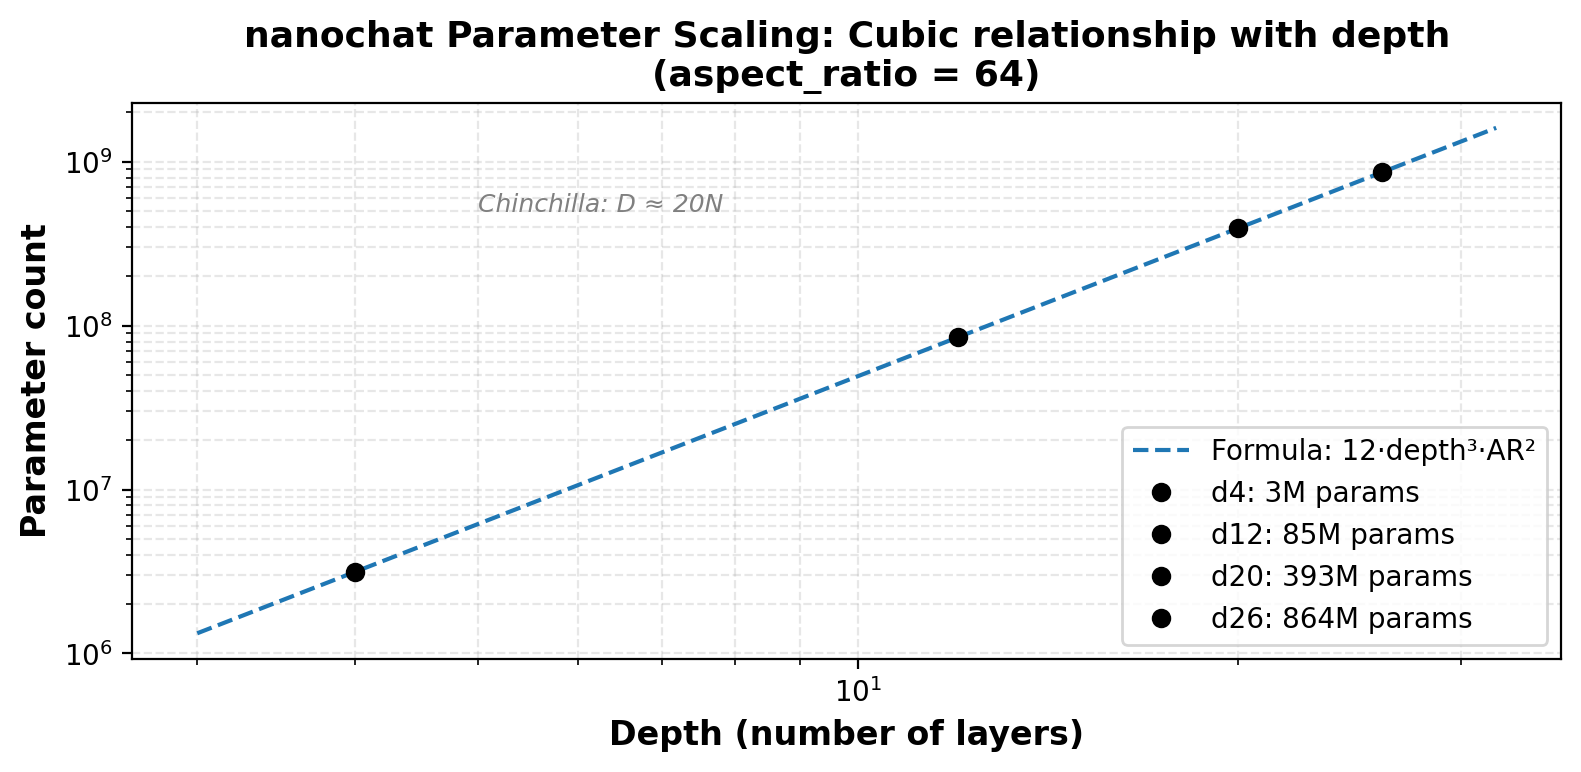


Cubic scaling: doubling depth increases parameters by ~8×
Example: depth 4→8: 8.0×
Example: depth 12→24: 8.0×


In [15]:
# Plot parameter count vs depth on log-log scale
depths = np.logspace(np.log10(3), np.log10(32), 50)
params_formula = [param_formula(d, aspect_ratio=64) for d in depths]

fig, ax = plt.subplots(figsize=(8, 4))

# Plot the cubic scaling curve
ax.loglog(depths, params_formula, '--', label='Formula: 12·depth³·AR²')

# Mark actual nanochat configs
nanochat_colors = {'d4': '#FF6B6B', 'd12': '#4ECDC4', 'd20': '#45B7D1', 'd26': '#96CEB4'}
for depth in [4, 12, 20, 26]:
    params = param_formula(depth, aspect_ratio=64)
    ax.loglog(depth, params, 'o', label=f'd{depth}: {params/1e6:.0f}M params', color='k')

# Add reference lines for compute-optimal training (Chinchilla: D ≈ 20N)
ax.text(5, 5e8, 'Chinchilla: D ≈ 20N', fontsize=9, style='italic', color='gray')

ax.set_xlabel('Depth (number of layers)', fontsize=12, fontweight='bold')
ax.set_ylabel('Parameter count', fontsize=12, fontweight='bold')
ax.set_title('nanochat Parameter Scaling: Cubic relationship with depth\n(aspect_ratio = 64)', 
            fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nCubic scaling: doubling depth increases parameters by ~8×")
print(f"Example: depth 4→8: {param_formula(8, 64)/param_formula(4, 64):.1f}×")
print(f"Example: depth 12→24: {param_formula(24, 64)/param_formula(12, 64):.1f}×")


## Data Preparation

We train on *TinyStories* ([Eldan & Li, 2023](https://arxiv.org/abs/2305.07759)) — a dataset of ~2.7 million short children's stories generated by GPT-3.5 and GPT-4 using a vocabulary of ~1,500 common words.

This is the standard benchmark corpus for tiny LLMs, and ideal for teaching:

- **Small models work**: even a 3M-parameter model produces coherent, grammatical stories
- **Fast convergence**: restricted vocabulary means the model generalises quickly
- **Interpretable output**: simple language makes quality easy to judge

The tokenizer was trained in `bpe-tokenizer.ipynb` and saved to `bpe_tokenizer.pkl`.
We load it here so the vocabulary is identical across all notebooks in the series.
With `vocab_size=512`, each token covers ~3–4 characters — roughly 3× shorter sequences than character-level.

In [16]:
# ── Load tokenizer from bpe-tokenizer.ipynb ──────────────────────────────────
# Run bpe-tokenizer.ipynb first to produce bpe_tokenizer.pkl.
vocab, merges = bpe_load('bpe_tokenizer.pkl')
print(f"Loaded tokenizer: vocab_size={len(vocab)}")

Loaded tokenizer: vocab_size=512


## Data Preparation

In [17]:
CACHE = "data/TinyStoriesV2-GPT4-valid.txt"
with open(CACHE, encoding='utf-8') as f:
    raw = f.read()
    
MAX_STORIES = 100_000
stories = [s.strip() for s in raw.split('<|endoftext|>') if s.strip()][:MAX_STORIES]
text    = "\n".join(stories)
print(f"Stories: {len(stories):,}  |  Characters: {len(text):,}")

Stories: 27,630  |  Characters: 22,095,533


In [18]:
context_len = 128
cache_path  = 'train_tokens.npy'

if os.path.exists(cache_path):
    seqs = np.load(cache_path)
    print(f"Loaded from cache: {len(seqs):,} sequences")
else:
    token_ids = np.array(bpe_encode(text, vocab, merges))
    print(f"Total tokens: {len(token_ids):,}  "
          f"(compression: {len(token_ids)/len(text):.3f} tokens/char)")
    seqs = np.stack([token_ids[i : i + context_len + 1]
                     for i in range(0, len(token_ids) - context_len - 1, context_len)])
    np.save(cache_path, seqs)
    print(f"Saved to cache: {cache_path}")

split = int(0.9 * len(seqs))
train_data, val_data = seqs[:split], seqs[split:]

print(f"Training sequences:   {len(train_data):,}")
print(f"Validation sequences: {len(val_data):,}")
print(f"Tokens per sequence:  {context_len}")

Loaded from cache: 60,916 sequences
Training sequences:   54,824
Validation sequences: 6,092
Tokens per sequence:  128


## Training

Key ideas:
- `jax.value_and_grad` computes loss and gradients in a single forward–backward pass
- `@jax.jit` traces the function once; subsequent calls execute compiled XLA code
- Parameters and optimiser state are immutable — each step returns new copies
- [optax](https://optax.readthedocs.io): a JAX optimiser library — we use `optax.adamw` (Adam + weight decay)
- We save checkpoints of the model to `.pkl` files.

In [19]:
n_steps   = 1_000
batch_size = 32
lr        = 3e-4
log_every = 100

optimizer = optax.adamw(lr, weight_decay=0.1)

In [20]:
vocab, merges = bpe_load('bpe_tokenizer.pkl')
vocab_size = len(vocab)

params, cfg = init_params(jax.random.key(0), vocab_size)
cfg['seq_len'] = context_len   # needed by nanochat-sft.ipynb
print("Config:", cfg)
print(f"Parameters: {count_params(params):,}")

cos_c, sin_c = precompute_rope(context_len, cfg['head_dim'])
mask_c = causal_mask(context_len)

Config: {'vocab_size': 512, 'd_model': 128, 'n_heads': 4, 'n_layers': 4, 'd_ff': 512, 'head_dim': 32, 'seq_len': 128}
Parameters: 918,656


In [21]:
@jax.jit
def train_step(params, opt_state, batch):
    def loss_fn(p):
        logits = forward(p, batch[:, :-1], cos_c, sin_c, mask_c)  # (B, T-1, V)
        B, T1, V = logits.shape
        return cross_entropy_loss(logits.reshape(B * T1, V), batch[:, 1:].reshape(-1))
    loss, grads = jax.value_and_grad(loss_fn, allow_int=True)(params)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

Here is the training loop:

In [22]:
opt_state    = optimizer.init(params)
train_losses = []
val_log      = []

key = jax.random.PRNGKey(0)
train_tokens = jnp.array(train_data)
val_tokens   = jnp.array(val_data)

Each line reports one checkpoint during training:

  - **step**: number of gradient updates completed (each update uses one randomly sampled minibatch of `batch_size` sequences)
  - **train**: mean cross-entropy loss (nats/token) on the last training batch
  - **val**: mean cross-entropy loss (nats/token) on a randomly sampled validation batch

  Both losses are averaged over every token prediction in the batch. To convert to perplexity: `exp(loss)` — e.g. a loss of 4.77 corresponds
  to perplexity ≈ 118.

In [23]:
for step in range(1, n_steps + 1):
    key, subkey = jax.random.split(key)
    idx = jax.random.randint(subkey, (batch_size,), 0, len(train_tokens))
    params, opt_state, loss = train_step(params, opt_state, train_tokens[idx])
    train_losses.append(float(loss))

    if step % log_every == 0:
        key, subkey = jax.random.split(key)
        idx_v = jax.random.randint(subkey, (batch_size,), 0, len(val_tokens))
        _, _, v_loss = train_step(params, opt_state, val_tokens[idx_v])
        val_log.append((step, float(v_loss)))
        print(f"step {step:5d} | train={train_losses[-1]:.3f} | val={float(v_loss):.3f}")

step   100 | train=4.766 | val=4.796
step   200 | train=4.223 | val=4.198
step   300 | train=3.987 | val=3.859
step   400 | train=3.708 | val=3.802
step   500 | train=3.627 | val=3.747
step   600 | train=3.611 | val=3.611
step   700 | train=3.438 | val=3.529
step   800 | train=3.411 | val=3.404
step   900 | train=3.423 | val=3.344
step  1000 | train=3.287 | val=3.348


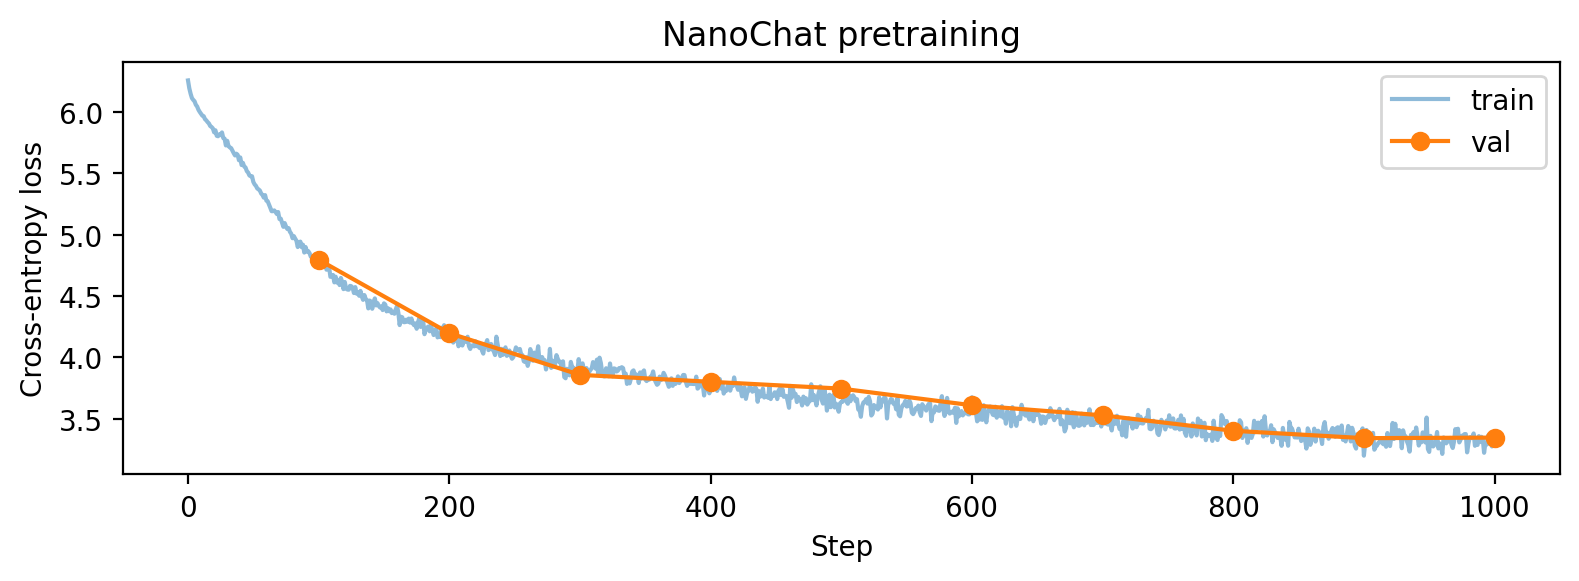

In [24]:
plt.figure(figsize=(8, 3))
plt.plot(train_losses, alpha=0.5, label='train')
if val_log:
    vs, vl = zip(*val_log)
    plt.plot(vs, vl, 'o-', label='val')
plt.xlabel('Step'); plt.ylabel('Cross-entropy loss')
plt.title('NanoChat pretraining'); plt.legend(); plt.tight_layout(); plt.show()

In [25]:
save_checkpoint(params, cfg, vocab, merges)

Checkpoint saved -> nanochat_checkpoint.pkl


## Text Generation

We implement **temperature**, **top-k**, and **top-p (nucleus)** sampling
as pure JAX functions.

| Method | Controls | Typical value |
|--------|----------|---------------|
| Temperature $\tau$ | sharpness of distribution | 0.7–1.0 |
| Top-k | cut to k most-likely tokens | 40 |
| Top-p | cut to cumulative mass $p$ | 0.9 |


In [30]:
def sample_token(key, logits, temperature=1.0, top_k=0, top_p=1.0):
    """Sample one token from logits. logits: (V,)"""
    logits = logits / temperature
    if top_k > 0:
        kth = jnp.sort(logits)[-top_k]
        logits = jnp.where(logits < kth, -jnp.inf, logits)
    probs = jax.nn.softmax(logits)
    if top_p < 1.0:
        sorted_idx  = jnp.argsort(-probs)
        cumsum      = jnp.cumsum(probs[sorted_idx])
        keep = jnp.concatenate([jnp.array([True]), cumsum[:-1] <= top_p])
        mask = jnp.zeros_like(probs).at[sorted_idx].set(keep.astype(probs.dtype))
        probs = probs * mask
        probs = probs / (probs.sum() + 1e-9)
    return int(jax.random.choice(key, probs.shape[0], p=probs))

In [31]:
def generate(params, vocab, merges, prompt, cfg,
             max_new_tokens=80, temperature=1.0, top_k=0, top_p=1.0, key=None):
    """Generate text autoregressively from a prompt string."""
    if key is None:
        key = jax.random.key(0)
    seq_len = cfg.get('seq_len', context_len)
    ids = bpe_encode(prompt, vocab, merges)
    for _ in range(max_new_tokens):
        ctx = ids[-seq_len:]
        T   = len(ctx)
        cos_g, sin_g = precompute_rope(T, cfg['head_dim'])
        mask_g       = causal_mask(T)
        logits = forward(params, jnp.array([ctx]), cos_g, sin_g, mask_g)
        key, sub = jax.random.split(key)
        ids.append(sample_token(sub, logits[0, -1], temperature, top_k, top_p))
    return bpe_decode(ids, vocab)

In [34]:
# Compare sampling strategies on a TinyStories-style prompt
prompt = "Once upon a time there was"
key = jax.random.key(1)
print("=== Temperature 0.5 (focused) ===")
print(generate(params, vocab, merges, prompt, cfg, max_new_tokens=80,
               temperature=0.5, key=key))

print("\n=== Temperature 1.0 (standard) ===")
print(generate(params, vocab, merges, prompt, cfg, max_new_tokens=80,
               temperature=1.0, key=key))

print("\n=== Top-k=10, Temperature=0.8 ===")
print(generate(params, vocab, merges, prompt, cfg, max_new_tokens=80,
               temperature=0.8, top_k=10, key=key))

print("\n=== Nucleus p=0.9 ===")
print(generate(params, vocab, merges, prompt, cfg, max_new_tokens=80,
               top_p=0.9, key=key))

=== Temperature 0.5 (focused) ===
Once upon a time there was always sunny day, there was a little boy named Tim. Tim loved to play with a big tree. He wanted to show what isit made her moment and do because he feeling to play in the lie sun in a big tree. The cat said, "You can I want to play with your toys!"
The bird said, "That's go ba

=== Temperature 1.0 (standard) ===
Once upon a time there was the mamy sun and day he bolized and day with the tast, flide.
Fluy run, the bottic started to car out, and them in the say fishing it arough and prettle to go to the lagain.
Tim's friends. She seowould go-up and the beay firean fun and 

=== Top-k=10, Temperature=0.8 ===
Once upon a time there was always lived in a smalls dog named Max and his friends. They had a sill at sind named Bust friendly boy named Tim. Tim loved to flot his friends. He wanted to play outside to sold the box with it. The dog went down in the park. He saw a big call and said, "Bober, you find a sorit!" 

=== Nucleus p

## Attention Visualisation

In JAX, extracting intermediate activations is trivial: modify `forward` to
also return attention weights (no hooks needed — everything is pure functional).


Prompt tokens: ["'On'", "'ce upon a tim'", "'e'"]


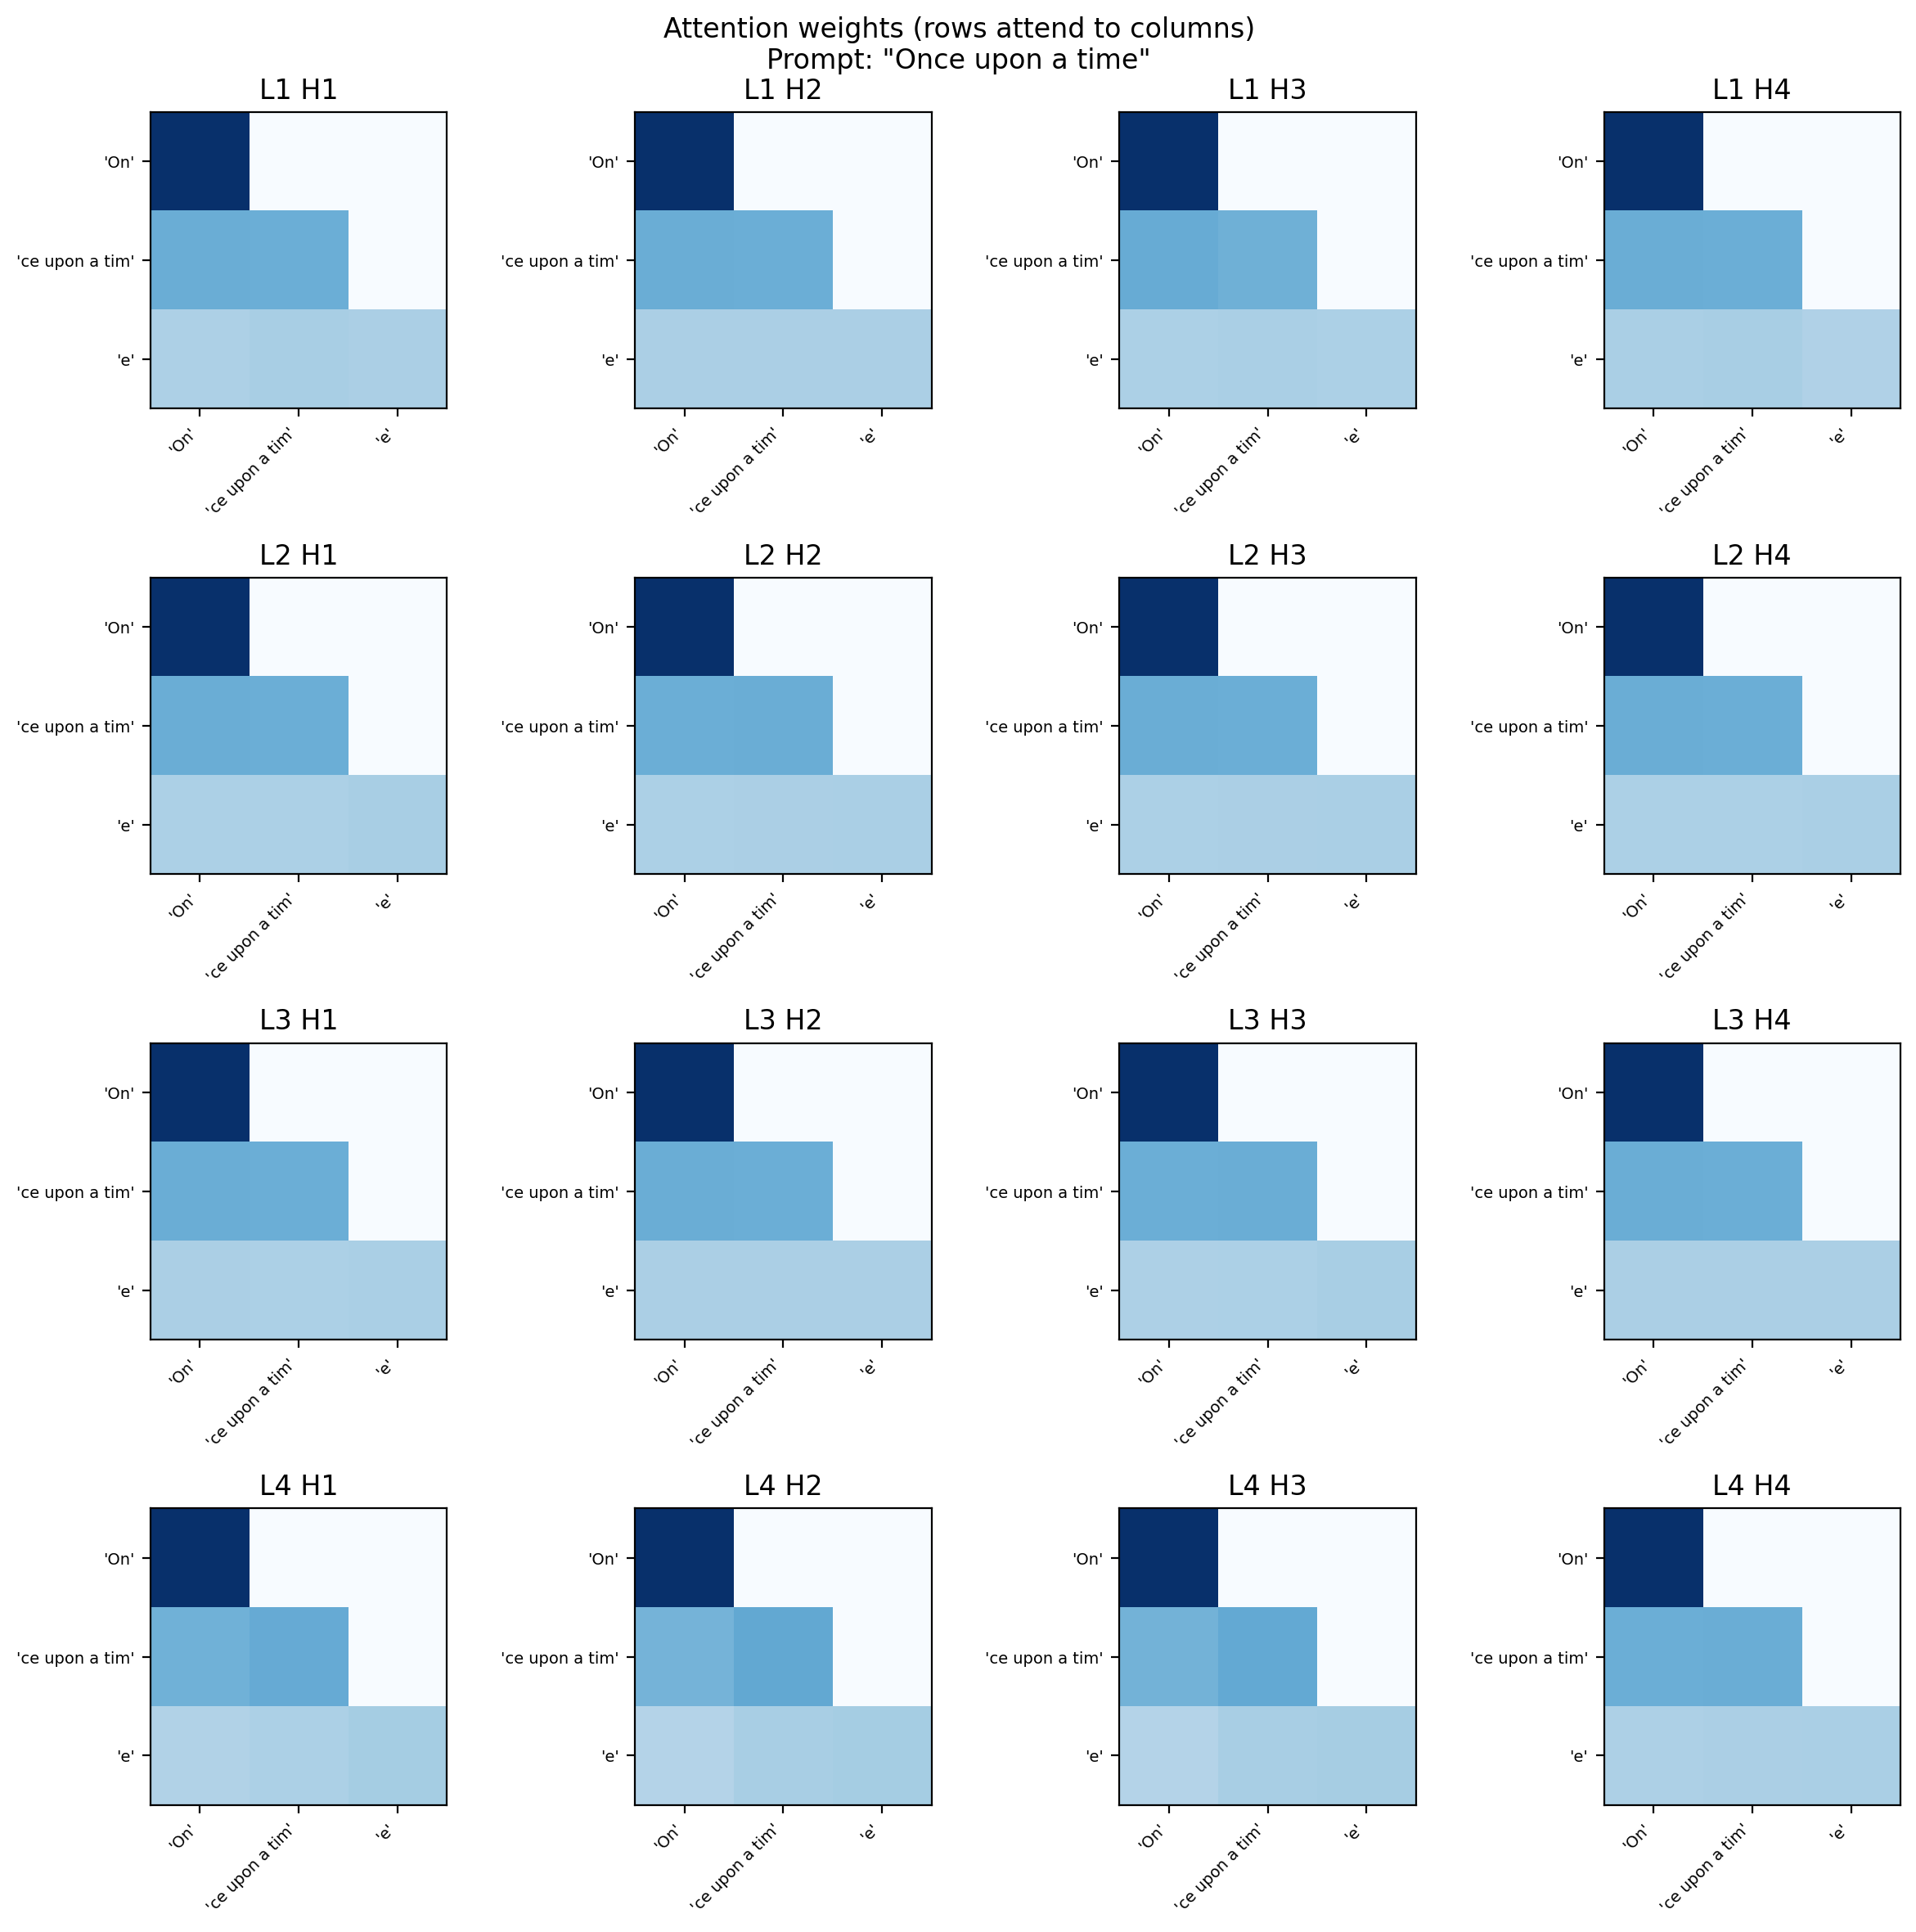

In [33]:
def forward_with_attn(params, token_ids, cos, sin, mask):
    """Like forward(), but also returns all layer attention weight matrices."""
    x = params['tok_emb']['W'][token_ids]
    all_weights = []
    for blk in params['blocks']:
        x_normed = rms_norm(blk['norm1']['g'], x)
        attn_out, weights = attention_forward(blk['attn'], x_normed, cos, sin, mask)
        all_weights.append(weights)
        x = x + attn_out
        x_normed = rms_norm(blk['norm2']['g'], x)
        x = x + mlp_forward(blk['mlp'], x_normed)
    x = rms_norm(params['norm_f']['g'], x)
    logits = x @ params['head']['W'].T
    return logits, all_weights   # list of (B, H, T, T)


sample_prompt = "Once upon a time"
prompt_ids = bpe_encode(sample_prompt, vocab, merges)
tok_strs   = [repr(vocab[i]) for i in prompt_ids]
ids_vis    = jnp.array([prompt_ids])
T_vis      = ids_vis.shape[1]
cos_v, sin_v = precompute_rope(T_vis, cfg['head_dim'])
mask_v       = causal_mask(T_vis)

print(f"Prompt tokens: {tok_strs}")

_, all_weights = forward_with_attn(params, ids_vis, cos_v, sin_v, mask_v)

n_layers = len(all_weights)
n_heads  = cfg['n_heads']
fig, axes = plt.subplots(n_layers, n_heads, figsize=(3 * n_heads, 3 * n_layers))
if n_layers == 1:
    axes = [axes]

for l, weights in enumerate(all_weights):
    for h in range(n_heads):
        ax = axes[l][h]
        w  = np.array(weights[0, h])
        ax.imshow(w, vmin=0, vmax=1, cmap='Blues')
        ax.set(title=f'L{l+1} H{h+1}',
               xticks=range(T_vis), yticks=range(T_vis))
        ax.set_xticklabels(tok_strs, fontsize=7, rotation=45, ha='right')
        ax.set_yticklabels(tok_strs, fontsize=7)

plt.suptitle(f'Attention weights (rows attend to columns)\nPrompt: "{sample_prompt}"',
             fontsize=12)
plt.tight_layout()
plt.show()

## Beyond Pretraining: The full nanochat pipeline

What we trained above is a language model that, given a prefix, predicts the next token.
It completes stories, but it does not follow instructions or reason about tasks.
nanochat trains through three stages so that it can be a chat assistant.

### Stage 1 — Pretraining *(this notebook)*

- **Data**: unlabelled text (TinyStories, FineWeb-EDU, …)
- **Objective**: next-token prediction (cross-entropy loss)
- **Result**: a model that knows the statistical structure of language

The model after pretraining has broad world knowledge but no notion of "answer a question"
or "be helpful". It will complete "What is 2+2?" with "…and the teacher said…" just as
plausibly as "…4." 

### Stage 2 — Supervised Fine-Tuning (SFT)

- **Data**: `(prompt, response)` pairs — human-written or GPT-4-generated
- **Objective**: same cross-entropy, but only on the *response* tokens (prompt is masked)
- **Result**: a model that reliably produces responses in the expected format

SFT is architecturally identical to pretraining — same model, same loss function, same
JAX training loop. Only the data format and masking change. The learning rate is typically
10–100× smaller to avoid catastrophic forgetting of pretraining knowledge.

```
Pretraining batch:    [t₁ t₂ t₃ … tₙ]          ← predict every token
SFT batch:            [prompt | response]         ← predict response tokens only
                       ←masked→ ←loss here→
```

### Stage 3 — GRPO (Group Relative Policy Optimization)

- **Data**: prompts with a **verifiable reward** (math problems, code with tests, …)
- **Objective**: maximise expected reward via policy gradient
- **Result**: a model that can *reason* — generating chains of thought that lead to correct answers

GRPO (Shao et al. 2024, used in DeepSeek-R1) is a simplified PPO variant:

1. For each prompt, sample $G$ responses from the current policy $\pi_\theta$
2. Score each response with reward $r_i$
3. Compute **group-relative advantage**: $\hat{A}_i = \frac{r_i - \text{mean}(r)}{\text{std}(r)}$
4. Update $\theta$ to increase probability of high-advantage responses

$$\mathcal{L}_{\text{GRPO}} = -\mathbb{E}\left[\sum_t \min\!\left(
\frac{\pi_\theta(a_t|s_t)}{\pi_{\text{old}}(a_t|s_t)} \hat{A},\;
\text{clip}\!\left(\frac{\pi_\theta}{\pi_{\text{old}}}, 1\pm\epsilon\right)\hat{A}
\right)\right] + \beta\, D_{\text{KL}}(\pi_\theta \| \pi_{\text{ref}})$$

The KL term keeps the model close to the SFT reference policy, preventing reward hacking.

**Why GRPO and not PPO?** GRPO removes the value network (critic) — advantages are
estimated from the group of $G$ sampled responses rather than a learned baseline.
This cuts memory and compute roughly in half.

### The nanochat pipeline in practice

```
pretrain on FineWeb-EDU  →  SFT on chat pairs  →  GRPO on math/reasoning
     ~hours (A4000)            ~minutes               ~minutes
```

SFT and GRPO on this notebook's tiny model are covered in `nanochat-sft.ipynb`
and `nanochat-grpo.ipynb`.

---
## nanochat vs modern LLMs

| Component | This notebook | nanochat (full) | LLaMA-3 / GPT-4 |
|-----------|--------------|-----------------|-----------------|
| Tokenisation | BPE (vocab=512, scratch) | BPE (vocab=64k, Rust) | BPE/Unigram |
| Positional encoding | RoPE | RoPE | RoPE |
| Normalisation | RMSNorm (pre) | RMSNorm | RMSNorm |
| Activation | ReLU² | ReLU² | SwiGLU (GELU) |
| Attention | Vanilla | Flash Attention 3 | Flash Attention 2/3 |
| KV cache | None | Immutable NamedTuple | Optimised |
| Optimizer | Adam (hand-rolled) | Muon + AdamW | AdamW + tuned LR |
| Fine-tuning | — (see nanochat-sft/grpo) | SFT + GRPO | RLHF / DPO / GRPO |
| Training data | TinyStories (sample) | FineWeb-EDU 10B tokens | Trillions of tokens |
| Parameters | < 1M | 37M – 1.5B | 7B – 70B+ |

The gap in scale is enormous, but every design principle in this notebook
appears in production models unchanged.

## Exercises

### Exercise 1: Scaling experiment
Train models with `d_model ∈ {64, 128, 256}` for 300 steps each. Plot
validation loss vs. parameter count. Does it follow a power law?

### Exercise 2: Replace RMSNorm with LayerNorm
Add a learnable bias $\mathbf{b}$ and mean subtraction:
$$\text{LayerNorm}(\mathbf{x}) = g \cdot \frac{\mathbf{x} - \mu}{\sigma + \epsilon} + b$$
Compare training stability and final loss with RMSNorm.

### Exercise 3: `jax.vmap` for per-sample gradients
Use `jax.vmap(jax.grad(per_sample_loss))` to compute per-example gradients.
How does per-example gradient variance evolve during training?

### Exercise 4: BPE vocabulary size ablation ★
Re-train the BPE tokenizer with `vocab_size ∈ {128, 256, 512, 1024}`.
For each, train the model and plot final validation BPT vs. vocab size.
Is there an optimal vocabulary size for this corpus and model?

### Exercise 5: Temperature calibration ★
Plot the entropy of the output distribution as a function of training step.
At what temperature does the model's output distribution best match the
empirical unigram distribution of TinyStories?

### Exercise 6: Biological sequences ★
Replace TinyStories with a protein sequence dataset (FASTA from UniProt).
The vocabulary is the 20 standard amino acids + gaps. What BPT do you achieve?
What subwords does BPE learn — do they correspond to known motifs?

### Exercise 7: `jax.lax.scan` training loop ★★
Replace the Python `for` loop in the training loop with `jax.lax.scan`
to avoid Python overhead per step. Measure the wall-clock speedup on CPU and GPU.

## References

1. **Karpathy (2025)** nanochat. [github.com/karpathy/nanochat](https://github.com/karpathy/nanochat)
2. **Vaswani et al. (2017)** Attention Is All You Need. *NeurIPS*.
3. **Su et al. (2021)** RoFormer: Enhanced Transformer with Rotary Position Embedding. arXiv:2104.09864.
4. **Sennrich et al. (2016)** Neural Machine Translation of Rare Words with Subword Units. *ACL*.
5. **Kaplan et al. (2020)** Scaling Laws for Neural Language Models. arXiv:2001.08361.
6. **Hoffmann et al. (2022)** Training Compute-Optimal Large Language Models (Chinchilla). arXiv:2203.15556.
7. **Eldan & Li (2023)** TinyStories: How Small Can Language Models Be and Still Speak Coherent English? arXiv:2305.07759.
8. **Shao et al. (2024)** DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models (GRPO). arXiv:2402.03300.
9. **Holtzman et al. (2020)** The Curious Case of Neural Text Degeneration. *ICLR*.
10. **Bradbury et al. (2018)** JAX: composable transformations of Python+NumPy programs. [github.com/google/jax](https://github.com/google/jax).